C:\Users\migue\AppData\Local\Temp\ipykernel_19516\1902292360.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


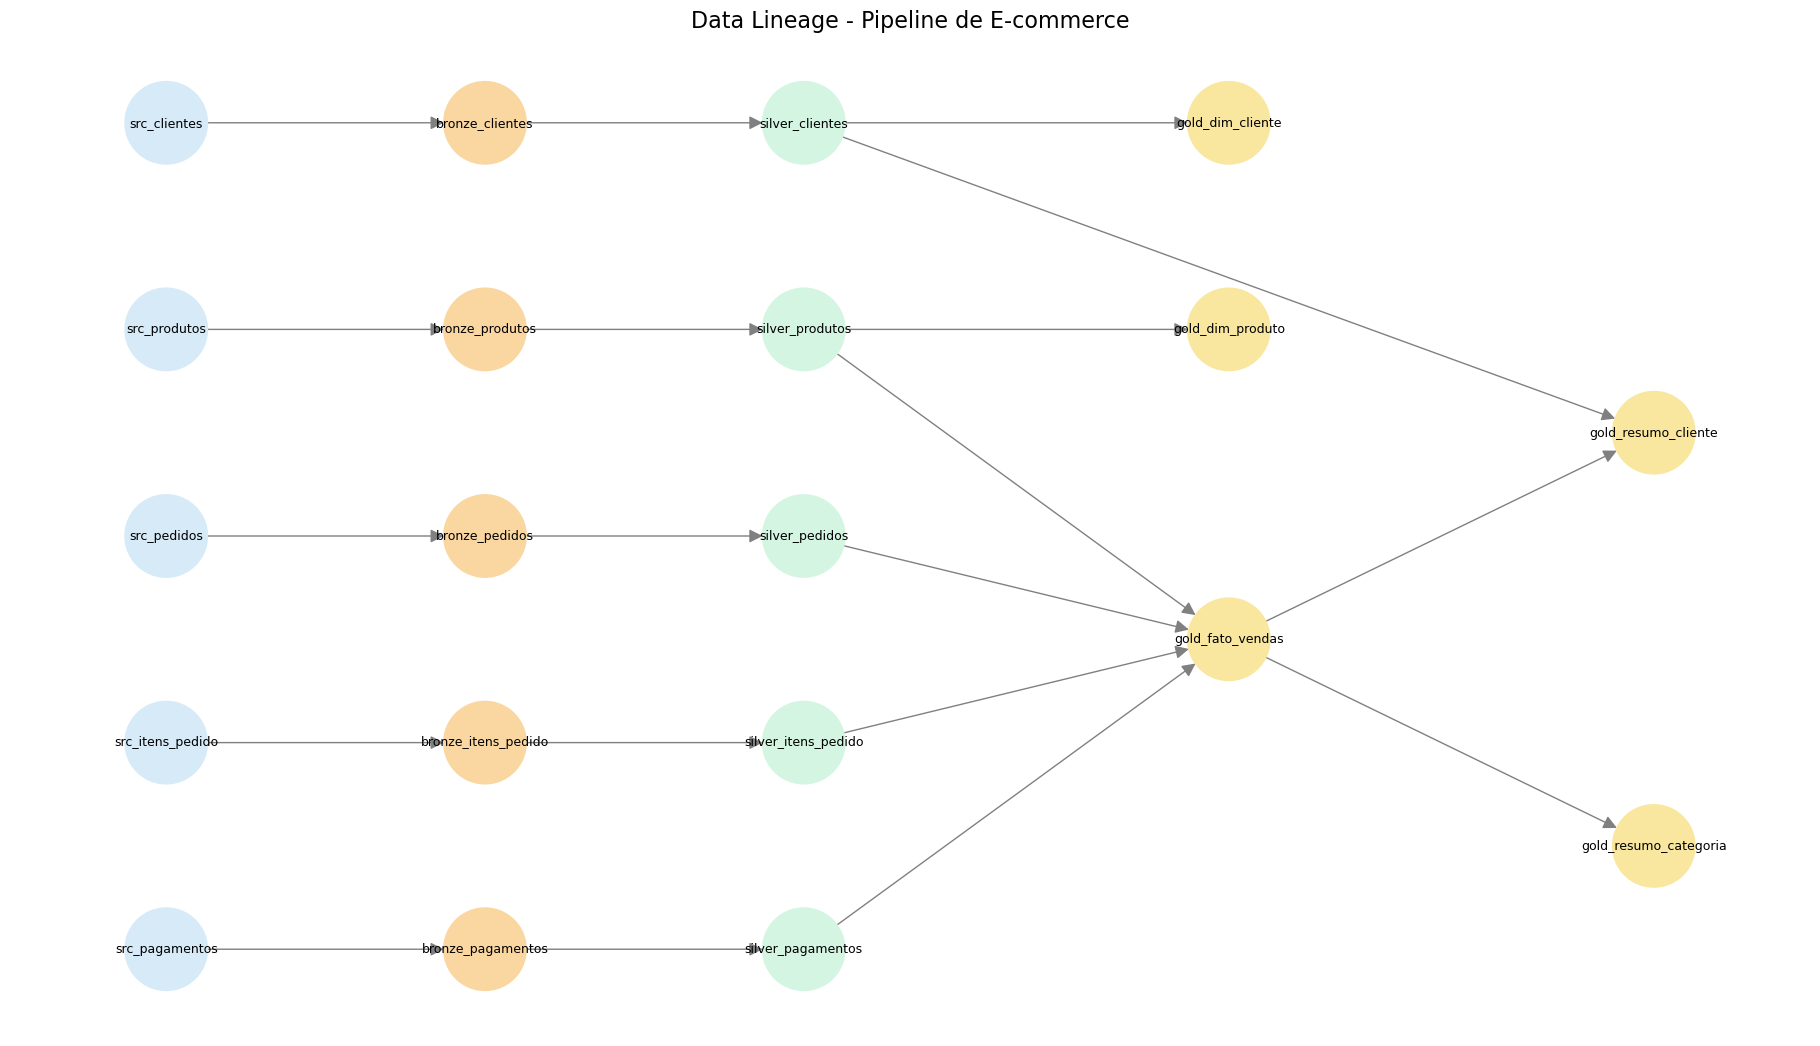

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# CRIA O GRAFO DIRECIONADO
# ==========================================
G = nx.DiGraph()

# ==========================================
# NÓS DO GRAFO
# ==========================================

# Camada Source
source_tables = [
    "src_clientes",
    "src_produtos",
    "src_pedidos",
    "src_itens_pedido",
    "src_pagamentos"
]

# Camada Bronze
bronze_tables = [
    "bronze_clientes",
    "bronze_produtos",
    "bronze_pedidos",
    "bronze_itens_pedido",
    "bronze_pagamentos"
]

# Camada Silver
silver_tables = [
    "silver_clientes",
    "silver_produtos",
    "silver_pedidos",
    "silver_itens_pedido",
    "silver_pagamentos"
]

# Camada Gold
gold_tables = [
    "gold_dim_cliente",
    "gold_dim_produto",
    "gold_fato_vendas",
    "gold_resumo_cliente",
    "gold_resumo_categoria"
]

# Adiciona todos os nós
for table in source_tables:
    G.add_node(table, camada="source")

for table in bronze_tables:
    G.add_node(table, camada="bronze")

for table in silver_tables:
    G.add_node(table, camada="silver")

for table in gold_tables:
    G.add_node(table, camada="gold")

# ==========================================
# ARESTAS - RELAÇÕES DE LINEAGE
# ==========================================

edges = [
    # Source -> Bronze
    ("src_clientes", "bronze_clientes"),
    ("src_produtos", "bronze_produtos"),
    ("src_pedidos", "bronze_pedidos"),
    ("src_itens_pedido", "bronze_itens_pedido"),
    ("src_pagamentos", "bronze_pagamentos"),

    # Bronze -> Silver
    ("bronze_clientes", "silver_clientes"),
    ("bronze_produtos", "silver_produtos"),
    ("bronze_pedidos", "silver_pedidos"),
    ("bronze_itens_pedido", "silver_itens_pedido"),
    ("bronze_pagamentos", "silver_pagamentos"),

    # Silver -> Gold dimensions
    ("silver_clientes", "gold_dim_cliente"),
    ("silver_produtos", "gold_dim_produto"),

    # Silver -> Gold fact
    ("silver_pedidos", "gold_fato_vendas"),
    ("silver_itens_pedido", "gold_fato_vendas"),
    ("silver_produtos", "gold_fato_vendas"),
    ("silver_pagamentos", "gold_fato_vendas"),

    # Gold fact + Silver client -> Gold resumo cliente
    ("gold_fato_vendas", "gold_resumo_cliente"),
    ("silver_clientes", "gold_resumo_cliente"),

    # Gold fact -> Gold resumo categoria
    ("gold_fato_vendas", "gold_resumo_categoria")
]

G.add_edges_from(edges)

# ==========================================
# POSIÇÃO MANUAL DOS NÓS
# ==========================================

pos = {
    # Source
    "src_clientes": (0, 8),
    "src_produtos": (0, 6),
    "src_pedidos": (0, 4),
    "src_itens_pedido": (0, 2),
    "src_pagamentos": (0, 0),

    # Bronze
    "bronze_clientes": (3, 8),
    "bronze_produtos": (3, 6),
    "bronze_pedidos": (3, 4),
    "bronze_itens_pedido": (3, 2),
    "bronze_pagamentos": (3, 0),

    # Silver
    "silver_clientes": (6, 8),
    "silver_produtos": (6, 6),
    "silver_pedidos": (6, 4),
    "silver_itens_pedido": (6, 2),
    "silver_pagamentos": (6, 0),

    # Gold
    "gold_dim_cliente": (10, 8),
    "gold_dim_produto": (10, 6),
    "gold_fato_vendas": (10, 3),
    "gold_resumo_cliente": (14, 5),
    "gold_resumo_categoria": (14, 1)
}

# ==========================================
# CORES POR CAMADA
# ==========================================

color_map = []

for node in G.nodes(data=True):
    camada = node[1]["camada"]

    if camada == "source":
        color_map.append("#D6EAF8")
    elif camada == "bronze":
        color_map.append("#FAD7A0")
    elif camada == "silver":
        color_map.append("#D5F5E3")
    elif camada == "gold":
        color_map.append("#F9E79F")
    else:
        color_map.append("#D7DBDD")

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(18, 10))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=3500,
    font_size=9,
    arrows=True,
    arrowsize=20,
    edge_color="gray",
    linewidths=1.2
)

plt.title("Data Lineage - Pipeline de E-commerce", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()